# Hybrid training for a small neural network: gradient descent inside, least squares outside

In this notebook we study a **hybrid training strategy** for a binary classifier on a nonlinear dataset.

The model has two parts:

- the **interior layers** of a small MLP are trained with **gradient descent**,
- the **last layer** is trained by solving a **ridge least-squares system** exactly.

In this setting, the matrix operations from the slides appear directly:

- least-squares systems,
- ill-conditioning,
- LU factorization,
- Cholesky factorization,
- the effect of regularization.


## Learning goals

By the end of the notebook you should be able to:

1. train a ridge classifier on the raw inputs as a linear baseline,
2. define a small MLP feature extractor and train its hidden layers by gradient descent,
3. solve exactly for the last-layer weights with a least-squares / ridge system,
4. analyze the conditioning of the last-layer system,
5. solve the same system with LU and Cholesky,
6. compare hybrid training with end-to-end gradient descent.


## 1. Load and visualize the dataset

The dataset is stored in a CSV file.
We will use the columns `x1`, `x2`, and `label`.


,x1,x2,label
0,0.195265,-1.069138,0
1,1.907424,-0.933508,1
2,-0.875661,-0.537700,0
3,-1.885132,-1.197602,1
4,0.062364,1.098066,0


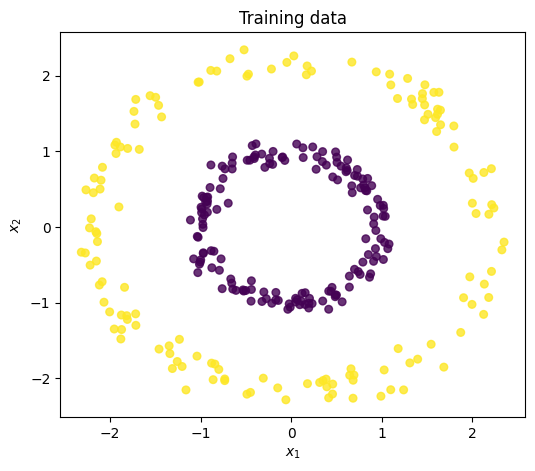

Training samples: 300
Test samples: 100


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp

np.set_printoptions(precision=4, suppress=True)

df = pd.read_csv('data/concentric_circles_data.csv')
display(df.head())

X = df[["x1", "x2"]].to_numpy(dtype=float)
y = df["label"].to_numpy(dtype=int)

rng = np.random.default_rng(7)
perm = rng.permutation(len(X))

n_train = int(0.75 * len(X))
train_idx = perm[:n_train]
test_idx = perm[n_train:]

X_train = X[train_idx]
X_test = X[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

plt.figure(figsize=(6, 5))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=30, alpha=0.8)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Training data")
plt.show()

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])


## 2. Standardize the inputs

Even though the dataset is only two-dimensional, it is good practice to standardize the features before training.
We compute the mean and standard deviation **using only the training set** and then apply the same transformation to the test set.


In [25]:

mu = X_train.mean(axis=0, keepdims=True)
sigma = X_train.std(axis=0, keepdims=True) + 1e-12

X_train_std = (X_train - mu) / sigma
X_test_std = (X_test - mu) / sigma

# For the least-squares classifier we use targets in {-1, +1}.
t_train = 2.0 * y_train - 1.0
t_test = 2.0 * y_test - 1.0

print("Mean of standardized training inputs:", X_train_std.mean(axis=0))
print("Std of standardized training inputs:", X_train_std.std(axis=0))


Mean of standardized training inputs: [-0. -0.]
Std of standardized training inputs: [1. 1.]


## 3. A linear baseline on the raw inputs

Before introducing a nonlinear model, let us solve a ridge least-squares problem directly on the raw standardized inputs.

We build the linear classifier

$$
s(x) = w_0 + w_1 x_1 + w_2 x_2
$$

and fit the coefficients by solving

$$
(X_b^T X_b + \lambda I) w = X_b^T t,
$$

where $X_b$ is the input matrix with a bias column of ones.


In [26]:

def add_bias_np(F):
    return np.hstack([np.ones((F.shape[0], 1)), F])

def ridge_weights_np(F, t, lam):
    Fb = add_bias_np(F)
    A = Fb.T @ Fb + lam * np.eye(Fb.shape[1])
    b = Fb.T @ t
    return np.linalg.solve(A, b)

def scores_np(F, w):
    return add_bias_np(F) @ w

def classification_accuracy(scores, y):
    return np.mean((scores >= 0).astype(int) == y)

lam_baseline = 1e-2

w_raw = ridge_weights_np(X_train_std, t_train, lam_baseline)

train_scores_raw = scores_np(X_train_std, w_raw)
test_scores_raw = scores_np(X_test_std, w_raw)

print("Linear baseline train accuracy:", classification_accuracy(train_scores_raw, y_train))
print("Linear baseline test accuracy: ", classification_accuracy(test_scores_raw, y_test))
print("Linear baseline weights:", w_raw)


Linear baseline train accuracy: 0.6666666666666666
Linear baseline test accuracy:  0.48
Linear baseline weights: [-0.06   -0.0338 -0.0328]


A linear model on the raw inputs struggles because the concentric circles are **not linearly separable**.
To improve the classifier, we will learn a nonlinear feature map with an MLP and keep the final readout layer linear.


## 4. Hidden layers by gradient descent, last layer by exact least squares

We now define a small MLP feature extractor

$$
x \longmapsto \phi_\theta(x),
$$

where $\theta$ contains the parameters of the hidden layers.

The final prediction is

$$
s(x) = w_0 + \phi_\theta(x)^T w.
$$

For a fixed feature matrix $F = \phi_\theta(X)$, the optimal last-layer coefficients solve the ridge system

$$
(F_b^T F_b + \lambda I) u = F_b^T t.
$$

So we use the following hybrid strategy:

1. update the hidden-layer parameters $\theta$ by gradient descent,
2. for the current hidden representation, solve **exactly** for the optimal head $w$.

This is a simple example of a **separable** model: part of the problem is optimized iteratively, and part is solved directly.


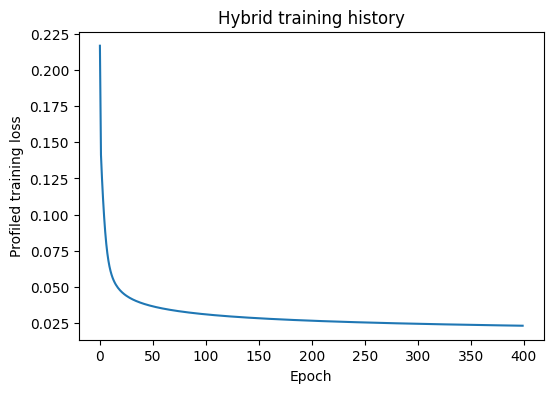

Hybrid model train accuracy: 1.0
Hybrid model test accuracy:  1.0
Dimension of the learned feature vector: 10


In [27]:

def initialize_hidden_params(layer_dims, seed=0):
    key = jax.random.PRNGKey(seed)
    params = []

    for n_in, n_out in zip(layer_dims[:-1], layer_dims[1:]):
        key, subkey = jax.random.split(key)
        scale = np.sqrt(2.0 / n_in)
        W = scale * jax.random.normal(subkey, shape=(n_in, n_out))
        b = jnp.zeros((n_out,))
        params.append({"W": W, "b": b})

    return params

def feature_map(params, X):
    A = X
    for layer in params:
        A = jnp.tanh(A @ layer["W"] + layer["b"])
    return A

def add_bias_jax(F):
    return jnp.concatenate([jnp.ones((F.shape[0], 1)), F], axis=1)

def ridge_head_jax(F, t, lam):
    Fb = add_bias_jax(F)
    A = Fb.T @ Fb + lam * jnp.eye(Fb.shape[1])
    b = Fb.T @ t
    return jnp.linalg.solve(A, b)

def profiled_loss(params, X, t, lam):
    F = feature_map(params, X)
    w_star = ridge_head_jax(F, t, lam)
    residual = add_bias_jax(F) @ w_star - t
    return jnp.mean(residual**2) + lam * jnp.sum(w_star**2) / X.shape[0]

profiled_grad = jax.jit(jax.grad(profiled_loss))

@jax.jit
def hybrid_step(params, X, t, lam, lr):
    grads = profiled_grad(params, X, t, lam)
    return jax.tree_util.tree_map(lambda p, g: p - lr * g, params, grads)

def train_hybrid_model(layer_dims, X, t, lam=1e-2, lr=5e-2, epochs=400, seed=0):
    params = initialize_hidden_params(layer_dims, seed=seed)
    history = []

    for _ in range(epochs):
        params = hybrid_step(params, X, t, lam, lr)
        history.append(float(profiled_loss(params, X, t, lam)))

    return params, np.array(history)

hidden_dims = [2, 16, 10]
lam_hybrid = 1e-2

X_train_jax = jnp.asarray(X_train_std)
X_test_jax = jnp.asarray(X_test_std)
t_train_jax = jnp.asarray(t_train)
t_test_jax = jnp.asarray(t_test)

hidden_params, hybrid_history = train_hybrid_model(
    hidden_dims,
    X_train_jax,
    t_train_jax,
    lam=lam_hybrid,
    lr=5e-2,
    epochs=400,
    seed=3,
)

F_train = np.asarray(feature_map(hidden_params, X_train_jax))
F_test = np.asarray(feature_map(hidden_params, X_test_jax))

w_head = np.asarray(ridge_head_jax(jnp.asarray(F_train), t_train_jax, lam_hybrid))

train_scores_hybrid = scores_np(F_train, w_head)
test_scores_hybrid = scores_np(F_test, w_head)

plt.figure(figsize=(6, 4))
plt.plot(hybrid_history)
plt.xlabel("Epoch")
plt.ylabel("Profiled training loss")
plt.title("Hybrid training history")
plt.show()

print("Hybrid model train accuracy:", classification_accuracy(train_scores_hybrid, y_train))
print("Hybrid model test accuracy: ", classification_accuracy(test_scores_hybrid, y_test))
print("Dimension of the learned feature vector:", F_train.shape[1])


The hybrid model behaves much more like a neural-network classifier: the hidden layers reshape the input into a more useful representation, and the final linear layer can then separate the classes much more easily.


## 5. Decision regions: linear baseline vs hybrid network

A useful way to visualize the improvement is to compare the decision regions of the two models.


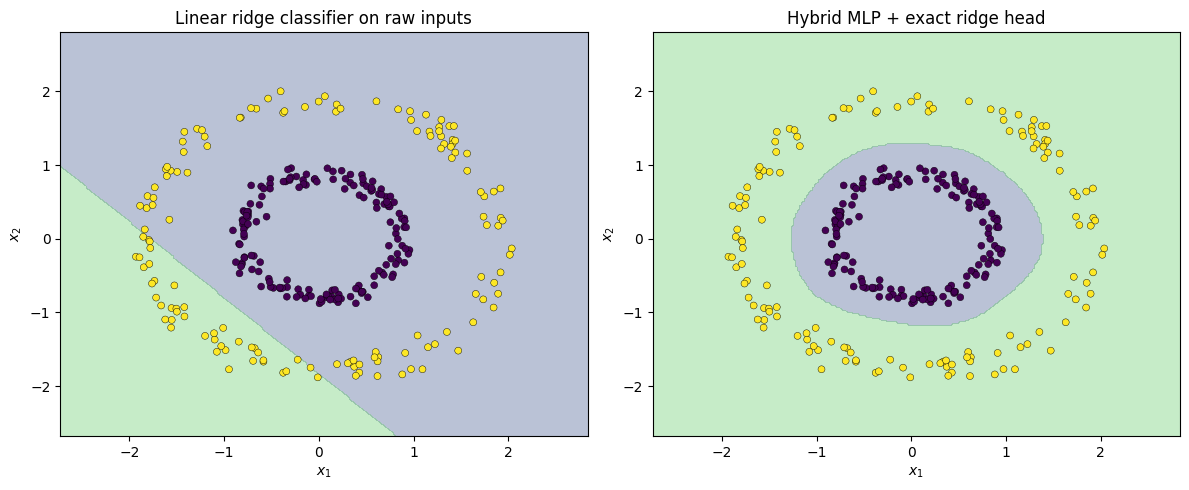

In [28]:

def make_grid(X_reference, n_points=250, padding=0.8):
    x1_min, x1_max = X_reference[:, 0].min() - padding, X_reference[:, 0].max() + padding
    x2_min, x2_max = X_reference[:, 1].min() - padding, X_reference[:, 1].max() + padding

    xx1, xx2 = np.meshgrid(
        np.linspace(x1_min, x1_max, n_points),
        np.linspace(x2_min, x2_max, n_points),
    )
    grid = np.column_stack([xx1.ravel(), xx2.ravel()])
    return xx1, xx2, grid

def predict_hybrid_scores(hidden_params, w_head, X):
    F = np.asarray(feature_map(hidden_params, jnp.asarray(X)))
    return scores_np(F, w_head)

xx1, xx2, grid = make_grid(X_train_std)

grid_scores_raw = scores_np(grid, w_raw).reshape(xx1.shape)
grid_scores_hybrid = predict_hybrid_scores(hidden_params, w_head, grid).reshape(xx1.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].contourf(xx1, xx2, grid_scores_raw >= 0, levels=1, alpha=0.35)
axes[0].scatter(X_train_std[:, 0], X_train_std[:, 1], c=y_train, s=25, edgecolor="k", linewidth=0.3)
axes[0].set_title("Linear ridge classifier on raw inputs")
axes[0].set_xlabel("$x_1$")
axes[0].set_ylabel("$x_2$")

axes[1].contourf(xx1, xx2, grid_scores_hybrid >= 0, levels=1, alpha=0.35)
axes[1].scatter(X_train_std[:, 0], X_train_std[:, 1], c=y_train, s=25, edgecolor="k", linewidth=0.3)
axes[1].set_title("Hybrid MLP + exact ridge head")
axes[1].set_xlabel("$x_1$")
axes[1].set_ylabel("$x_2$")

plt.tight_layout()
plt.show()


## 6. Redundant learned features and conditioning

In deep models, learned features can become **correlated** or even nearly redundant.
That matters because the last-layer ridge system depends on the feature matrix.

To illustrate this, we create an augmented representation by adding a few almost-duplicate learned channels and compare condition numbers.


In [29]:

def ridge_system(F, t, lam):
    Fb = add_bias_np(F)
    A = Fb.T @ Fb + lam * np.eye(Fb.shape[1])
    b = Fb.T @ t
    return A, b

F_train_redundant = np.column_stack([
    F_train,
    F_train[:, [0]],
    F_train[:, [0]] + 1e-3 * F_train[:, [1]],
    0.5 * F_train[:, [2]] - 0.5 * F_train[:, [3]],
])

lam_values = [1e-8, 1e-4, 1e-2]

print("cond(F_train):", np.linalg.cond(F_train))
print("cond(F_train_redundant):", np.linalg.cond(F_train_redundant))
print()

for lam in lam_values:
    A_clean, _ = ridge_system(F_train, t_train, lam)
    A_redundant, _ = ridge_system(F_train_redundant, t_train, lam)

    print(f"lambda = {lam:.0e}")
    print("  cond(clean ridge matrix)    :", np.linalg.cond(A_clean))
    print("  cond(redundant ridge matrix):", np.linalg.cond(A_redundant))
    print()


cond(F_train): 50.102604
cond(F_train_redundant): 1.0222772e+16

lambda = 1e-08
  cond(clean ridge matrix)    : 2786.110580619954
  cond(redundant ridge matrix): 91101585348.66165

lambda = 1e-04
  cond(clean ridge matrix)    : 2784.9006650166275
  cond(redundant ridge matrix): 9109526.355351325

lambda = 1e-02
  cond(clean ridge matrix)    : 2670.0970342352243
  cond(redundant ridge matrix): 91096.2528730858



The redundant representation is much more ill-conditioned.
Regularization helps, but the main lesson is that the quality of the learned features matters numerically, not only statistically.


## 7. A general direct method: LU factorization

Let us now solve the last-layer ridge system with a direct method based on LU factorization.

Since our ridge matrix is symmetric positive definite for $\lambda > 0$, LU without pivoting is fine in this example.


In [30]:

def forward_substitution(L, b):
    n = L.shape[0]
    z = np.zeros_like(b, dtype=float)

    for i in range(n):
        z[i] = (b[i] - L[i, :i] @ z[:i]) / L[i, i]

    return z

def backward_substitution(U, z):
    n = U.shape[0]
    x = np.zeros_like(z, dtype=float)

    for i in range(n - 1, -1, -1):
        x[i] = (z[i] - U[i, i + 1:] @ x[i + 1:]) / U[i, i]

    return x

def doolittle_lu(A):
    n = A.shape[0]
    L = np.eye(n)
    U = np.zeros_like(A, dtype=float)

    for k in range(n):
        U[k, k:] = A[k, k:] - L[k, :k] @ U[:k, k]

        for i in range(k + 1, n):
            L[i, k] = (A[i, k] - L[i, :k] @ U[:k, k]) / U[k, k]

    return L, U

def lu_solve(A, b):
    L, U = doolittle_lu(A)
    z = forward_substitution(L, b)
    x = backward_substitution(U, z)
    return x, L, U

A_lu, rhs_lu = ridge_system(F_train_redundant, t_train, lam=1e-2)

w_lu, L_lu, U_lu = lu_solve(A_lu, rhs_lu)
w_np = np.linalg.solve(A_lu, rhs_lu)

print("||A - LU||:", np.linalg.norm(A_lu - L_lu @ U_lu))
print("||w_lu - w_np||:", np.linalg.norm(w_lu - w_np))


||A - LU||: 19731.609854091635
||w_lu - w_np||: 26.039806019590163


## 8. A specialized SPD method: Cholesky factorization

For a ridge system, Cholesky is especially natural because

$$
A = F_b^T F_b + \lambda I
$$

is symmetric positive definite whenever $\lambda > 0$.


In [31]:

def cholesky_solve(A, b):
    L = np.linalg.cholesky(A)
    z = forward_substitution(L, b)
    x = backward_substitution(L.T, z)
    return x, L

A_chol, rhs_chol = ridge_system(F_train_redundant, t_train, lam=1e-2)

w_chol, L_chol = cholesky_solve(A_chol, rhs_chol)

print("||A - L L^T||:", np.linalg.norm(A_chol - L_chol @ L_chol.T))
print("||w_chol - w_np||:", np.linalg.norm(w_chol - w_np))


||A - L L^T||: 1.1462707291462311e-13
||w_chol - w_np||: 8.449621128658446e-12


In this setting, Cholesky uses the symmetry and positive definiteness of the system and is therefore more specialized than LU.


## 9. Effect of the regularization parameter

Let us vary $\lambda$ and observe two things:

- the condition number of the ridge matrix,
- the test accuracy of the final classifier.

This shows the classical trade-off:
larger regularization often improves numerical conditioning, but too much regularization may hurt predictive performance.


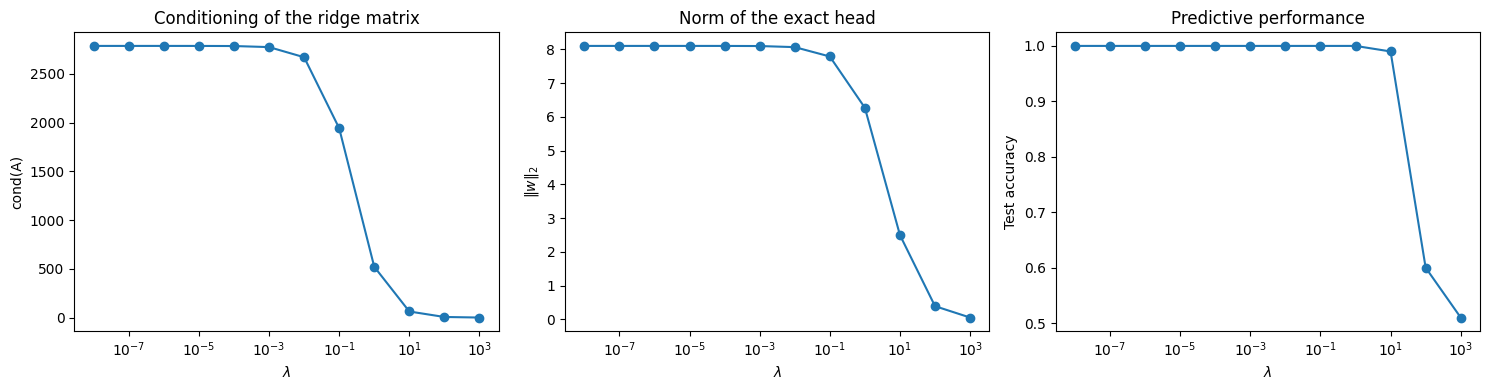

In [32]:

lambda_grid = np.logspace(-8, 3, 12)

cond_values = []
test_acc_values = []
head_norm_values = []

for lam in lambda_grid:
    w_lam = ridge_weights_np(F_train, t_train, lam)
    A_lam, _ = ridge_system(F_train, t_train, lam)

    cond_values.append(np.linalg.cond(A_lam))
    test_acc_values.append(classification_accuracy(scores_np(F_test, w_lam), y_test))
    head_norm_values.append(np.linalg.norm(w_lam))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].semilogx(lambda_grid, cond_values, marker="o")
axes[0].set_xlabel(r"$\lambda$")
axes[0].set_ylabel("cond(A)")
axes[0].set_title("Conditioning of the ridge matrix")

axes[1].semilogx(lambda_grid, head_norm_values, marker="o")
axes[1].set_xlabel(r"$\lambda$")
axes[1].set_ylabel(r"$\|w\|_2$")
axes[1].set_title("Norm of the exact head")

axes[2].semilogx(lambda_grid, test_acc_values, marker="o")
axes[2].set_xlabel(r"$\lambda$")
axes[2].set_ylabel("Test accuracy")
axes[2].set_title("Predictive performance")

plt.tight_layout()
plt.show()


## 10. Hybrid training vs end-to-end gradient descent

Finally, let us compare the hybrid strategy with a more standard approach:
train **all** parameters by gradient descent, including the last layer.

This is not meant to prove that one method is always better.
The goal is simply to compare

- an **exact solve** for the head at every iteration,
- versus a **fully iterative** optimization.


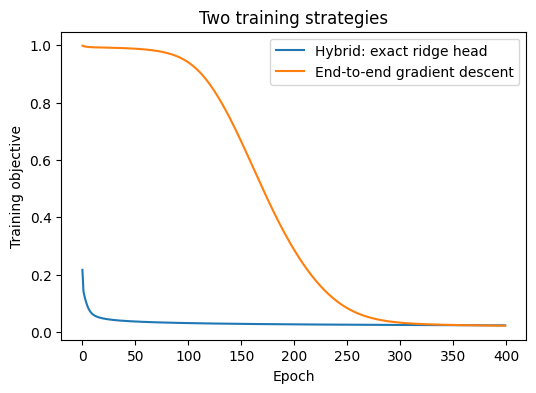

Hybrid test accuracy:         1.0
End-to-end GD test accuracy: 1.0


In [33]:

def full_model_loss(params, w, X, t, lam):
    F = feature_map(params, X)
    scores = add_bias_jax(F) @ w
    residual = scores - t
    return jnp.mean(residual**2) + lam * jnp.sum(w**2) / X.shape[0]

full_grad = jax.jit(jax.grad(full_model_loss, argnums=(0, 1)))

@jax.jit
def full_gd_step(params, w, X, t, lam, lr_hidden, lr_head):
    grad_params, grad_w = full_grad(params, w, X, t, lam)
    params = jax.tree_util.tree_map(lambda p, g: p - lr_hidden * g, params, grad_params)
    w = w - lr_head * grad_w
    return params, w

def train_full_gd(layer_dims, X, t, lam=1e-2, lr_hidden=5e-2, lr_head=5e-2, epochs=400, seed=0):
    params = initialize_hidden_params(layer_dims, seed=seed)
    w = jnp.zeros((layer_dims[-1] + 1,))
    history = []

    for _ in range(epochs):
        params, w = full_gd_step(params, w, X, t, lam, lr_hidden, lr_head)
        history.append(float(full_model_loss(params, w, X, t, lam)))

    return params, np.asarray(w), np.array(history)

full_params, full_w, full_history = train_full_gd(
    hidden_dims,
    X_train_jax,
    t_train_jax,
    lam=lam_hybrid,
    lr_hidden=5e-2,
    lr_head=5e-2,
    epochs=400,
    seed=3,
)

F_test_full = np.asarray(feature_map(full_params, X_test_jax))
test_scores_full = scores_np(F_test_full, full_w)

plt.figure(figsize=(6, 4))
plt.plot(hybrid_history, label="Hybrid: exact ridge head")
plt.plot(full_history, label="End-to-end gradient descent")
plt.xlabel("Epoch")
plt.ylabel("Training objective")
plt.title("Two training strategies")
plt.legend()
plt.show()

print("Hybrid test accuracy:        ", classification_accuracy(test_scores_hybrid, y_test))
print("End-to-end GD test accuracy:", classification_accuracy(test_scores_full, y_test))


## 11. Discussion

1. **Why does a linear model fail on the raw concentric-circle inputs?** Because the two classes are not linearly separable in the original $(x_1,x_2)$ space. A straight line cannot separate the inner circle from the outer ring.
3. **Why is the last-layer training problem a ridge least-squares system?** Once the hidden features are fixed, the output is linear in the last-layer weights. Minimizing the squared loss with an $L_2$ penalty leads to
   $$
   (Z^T Z + \lambda I)u = Z^T y,
   $$
   which is exactly a ridge least-squares system.
4. **Why does adding nearly redundant learned features hurt conditioning?** Because some columns of the feature matrix become almost linearly dependent. Then $Z^T Z$ becomes close to singular, and small perturbations can cause large changes in the solution.
6. **Why is Cholesky especially natural for the ridge matrix?**  The matrix $Z^T Z + \lambda I$ is symmetric, and for $\lambda>0$ it is positive definite. Cholesky is designed exactly for symmetric positive definite systems and is more efficient than a general solver.
7. **When might one prefer an exact head solve over gradient descent on the head?**  When the last-layer problem is small or moderate in size and we want the exact minimizer quickly and reliably. Gradient descent may still be preferred when the head is very large or when everything is trained jointly end to end.
8. **How does the regularization parameter affect both stability and accuracy?** Increasing $\lambda$ usually improves conditioning and makes the solution more stable, but too much regularization can underfit the data and reduce accuracy. A moderate value often gives the best trade-off.
